In [1]:
!pip install requests beautifulsoup4 pandas -q

import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import urllib.parse
from google.colab import files

keyword = "python book"
keyword_encoded = urllib.parse.quote(keyword)
base_url = f"https://www.ebay.com/sch/i.html?_nkw={keyword_encoded}&_sacat=0&_pgn="

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/134.0.0.0 Safari/537.36 Edg/134.0.0.0",
    "Accept-Language": "en-US,en;q=0.9,ar;q=0.8",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,*/*;q=0.8",
    "Referer": "https://www.ebay.com/",
    "Connection": "keep-alive",
    "Upgrade-Insecure-Requests": "1"
}

all_products = []
max_pages = 3

for page in range(1, max_pages + 1):
    url = base_url + str(page)
    print(f"Scraping Page {page}: {url}")

    try:
        response = requests.get(url, headers=headers, timeout=12)
        print(f"Status Code: {response.status_code}")
        if response.status_code != 200:
            print("-> Potential Block (403/429/Checking browser)")
            break
    except Exception as e:
        print(f"Connection Error: {e}")
        break

    soup = BeautifulSoup(response.text, "html.parser")
    items = soup.select("li.s-item, li.s-item__pl-on-bottom, div.s-item__wrapper, li.s-card")

    if not items:
        print("-> No items found. Possible JS/Dynamic content or blocking. Try Selenium or API.")
        print(soup.prettify()[:800])
        break

    for item in items:
        title = item.select_one(".s-item__title, .s-card__title, h3, [role='heading']")
        title_text = title.get_text(strip=True) if title else "Not Available"

        price = item.select_one(".s-item__price, .s-card__price, span[itemprop='price']")
        price_text = price.get_text(strip=True) if price else "Not Available"

        img = item.select_one("img.s-item__image-img, img")
        img_url = img.get("src") or img.get("data-src") if img else "Not Available"

        link = item.select_one("a.s-item__link, a[href*='itm/']")
        link_url = link.get("href") if link else "Not Available"
        if "Shop on eBay" in title_text:
            continue
        all_products.append({
            "Page": page,
            "Name": title_text,
            "Price": price_text,
            "Image": img_url,
            "Link": link_url
        })
    time.sleep(4)

if all_products:
    df = pd.DataFrame(all_products)
    filename = f"ebay_{keyword.replace(' ', '_')}_2026.csv"
    df.to_csv(filename, index=False, encoding="utf-8-sig")
    print(f"\nSaved {len(all_products)} products to {filename}")
    display(df.head(10))
    files.download(filename)
else:
    print("Empty Results -> Selenium or API (like SerpApi from the lecture) might be required.")

print("Process Finished.")

Scraping Page 1: https://www.ebay.com/sch/i.html?_nkw=python%20book&_sacat=0&_pgn=1
Status Code: 403
-> Potential Block (403/429/Checking browser)
Empty Results -> Selenium or API (like SerpApi from the lecture) might be required.
Process Finished.


In [2]:
!pip uninstall serpapi -y
!pip install google-search-results

  Preparing metadata (setup.py) ... done
  Created wheel for google-search-results: filename=google_search_results-2.4.2-py3-none-any.whl size=32010 sha256=af33477b9e16a4811781a964e54f273bf42b071cd85a54a10d097adcba536230
  Stored in directory: /root/.cache/pip/wheels/0c/47/f5/89b7e770ab2996baf8c910e7353d6391e373075a0ac213519e
Successfully built google-search-results


https://www.alphavantage.co/query?function=INCOME_STATEMENT&symbol=EBAY&apikey=TR6AOWFWBP1ROI3T


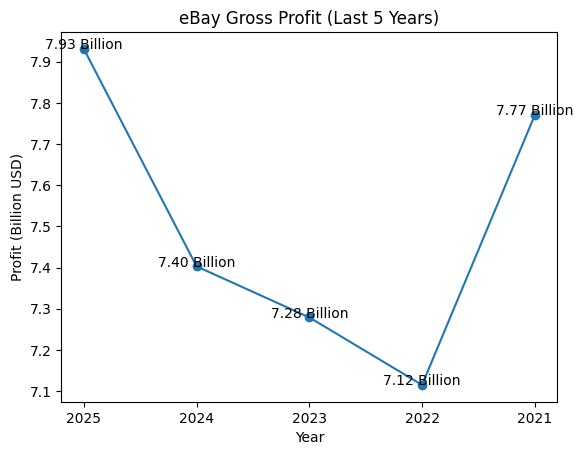

In [3]:
import requests
# جيبت api من alphavantage عشان اعرف ارباحهم في اخر 5 سنين
api_key = "TR6AOWFWBP1ROI3T"

# رمزهم في البورصه
symbol = "EBAY"

url = f"https://www.alphavantage.co/query?function=INCOME_STATEMENT&symbol={symbol}&apikey={api_key}"
print(url)

res = requests.get(url)
data = res.json()

# يجيبلي تقارير السنه
reports = data["annualReports"][:5]

import matplotlib.pyplot as plt

years = []
profits = []

for r in reports:
    # اخد جزء من التاريخ الي هو السنه بس و يحطها في الليست الفاضيه
    years.append(r["fiscalDateEnding"][:4])

    # احول الربح لمليار
    profits.append(int(r["grossProfit"]) / 1e9)

# ارسم الجراف و احط نقط على كل سنة
plt.plot(years, profits, marker='o')

# عنوان الرسم
plt.title("eBay Gross Profit (Last 5 Years)")

# تسمية المحاور
plt.xlabel("Year")
plt.ylabel("Profit (Billion USD)")

# اكتب الرقم جنب كل نقطة بالمليار
for i in range(len(years)):
    plt.text(years[i], profits[i], f"{profits[i]:.2f} Billion", ha='center')

plt.show()

In [5]:
!pip uninstall serpapi -y
!pip install google-search-results
from serpapi.google_search import GoogleSearch
import requests
from bs4 import BeautifulSoup
import pandas as pd
search = GoogleSearch({
    "engine": "ebay",
    "_nkw": "python book",
    "ebay_domain": "ebay.com",
    "_ipg": "100",
    "api_key": "28f77b83a2d00f1b296a67f3347667f0d52a164c8183191a38271b5ed8829a60"
})
result = search.get_dict()
result
org_res = result["organic_results"]
data = []
for item in org_res:
    data.append({
        "title": item.get("title"),
        "price": item.get("price"),
        "shipping": item.get("shipping"),
        "condition": item.get("condition"),
        "link": item.get("link"),
        "item_id": item.get("item_id"),
        "rating": item.get("rating"),
        "reviews": item.get("reviews")
    })
df = pd.DataFrame(data)
df

df.to_csv("ebay_book.csv", index=False, encoding="utf-8-sig")
df

,title,price,shipping,condition,link,item_id,rating,reviews
0,Deep Learning with Python Second Edition Franc...,"{'raw': '$25.00', 'extracted': 25.0}",Free delivery,Pre-Owned,https://www.ebay.com/itm/236610777699?_skw=pyt...,None,NaN,NaN
1,"Python Programming for the Absolute Beginner, ...","{'raw': '$5.90', 'extracted': 5.9}",Free delivery,Pre-Owned,https://www.ebay.com/itm/196893208474?_skw=pyt...,None,5.0,6.0
2,"Python Programming for the Absolute Beginner, ...","{'raw': '$7.39', 'extracted': 7.39}",Free delivery,Pre-Owned,https://www.ebay.com/itm/196892113887?_skw=pyt...,None,5.0,6.0
3,No Starch Press PYTHON BOOK LOT of 4- Programm...,"{'raw': '$55.00', 'extracted': 55.0}","{'raw': '+$9.72 delivery', 'extracted': 9.72}",New (Other),https://www.ebay.com/itm/147290247706?_skw=pyt...,None,NaN,NaN
4,Programming Python: Powerful Object-Oriented P...,"{'raw': '$8.93', 'extracted': 8.93}",Free delivery,Pre-Owned,https://www.ebay.com/itm/358399923957?_skw=pyt...,None,5.0,1.0
...,...,...,...,...,...,...,...,...
115,"Python Machine Learning - paperback Lee, Wei-Meng","{'raw': '$10.52', 'extracted': 10.52}",Free delivery,Pre-Owned,https://www.ebay.com/itm/187791868424?_skw=pyt...,None,NaN,NaN
116,Numerical Python in Astronomy and Astrophysics...,"{'raw': '$35.99', 'extracted': 35.99}","{'raw': '+$5.22 delivery in 2-4 days', 'extrac...",New (Other),https://www.ebay.com/itm/277473551844?_skw=pyt...,None,NaN,NaN
117,"Python in a Day : Learn the Basics, Learn It Q...","{'raw': '$6.41', 'extracted': 6.41}",Free delivery,Pre-Owned,https://www.ebay.com/itm/317655323276?_skw=pyt...,None,NaN,NaN
118,"Python Essential Reference by Beazley, David","{'raw': '$6.19', 'extracted': 6.19}",Free delivery,Pre-Owned,https://www.ebay.com/itm/146439277572?_skw=pyt...,None,5.0,1.0


In [6]:
import pandas as pd
df_scraping = pd.DataFrame(all_products)
df_scraping['Source'] = 'BeautifulSoup'
df_api = pd.DataFrame(df)
df_api['Source'] = 'API'
df_api = df_api.rename(columns={'title': 'Name'})
final_df = pd.concat([df_scraping, df_api], ignore_index=True)
final_df.drop_duplicates(subset=['Name'], keep='first', inplace=True)
final_df.to_csv('Final_Project_Data.csv', index=False, encoding='utf-8-sig')
print("Successfully merged your Scraping data with the API data!")
print(f"Total unique products collected: {len(final_df)}")
display(final_df.head(10))

Successfully merged your Scraping data with the API data!
Total unique products collected: 106


,Source,Name,price,shipping,condition,link,item_id,rating,reviews
0,API,Deep Learning with Python Second Edition Franc...,"{'raw': '$25.00', 'extracted': 25.0}",Free delivery,Pre-Owned,https://www.ebay.com/itm/236610777699?_skw=pyt...,None,NaN,NaN
1,API,"Python Programming for the Absolute Beginner, ...","{'raw': '$5.90', 'extracted': 5.9}",Free delivery,Pre-Owned,https://www.ebay.com/itm/196893208474?_skw=pyt...,None,5.0,6.0
3,API,No Starch Press PYTHON BOOK LOT of 4- Programm...,"{'raw': '$55.00', 'extracted': 55.0}","{'raw': '+$9.72 delivery', 'extracted': 9.72}",New (Other),https://www.ebay.com/itm/147290247706?_skw=pyt...,None,NaN,NaN
4,API,Programming Python: Powerful Object-Oriented P...,"{'raw': '$8.93', 'extracted': 8.93}",Free delivery,Pre-Owned,https://www.ebay.com/itm/358399923957?_skw=pyt...,None,5.0,1.0
5,API,Python Programming Books Set: Python Programmi...,"{'raw': '$20.24', 'extracted': 20.24}",Free delivery in 2-4 days,Brand New,https://www.ebay.com/itm/184095343932?_skw=pyt...,None,NaN,NaN
6,API,Python for Kids: A Playful Introduction to Pro...,"{'raw': '$5.26', 'extracted': 5.26}",Free delivery,Pre-Owned,https://www.ebay.com/itm/256101590249?_skw=pyt...,None,5.0,7.0
7,API,Coding Projects in Python - Paperback By DK - ...,"{'raw': '$5.30', 'extracted': 5.3}",Free delivery,Pre-Owned,https://www.ebay.com/itm/277101611255?_skw=pyt...,None,5.0,2.0
8,API,"The Quick Python Book - Paperback By Ceder, Na...","{'raw': '$5.98', 'extracted': 5.98}",Free delivery,Pre-Owned,https://www.ebay.com/itm/256150929073?_skw=pyt...,None,4.0,1.0
9,API,Creative Coding in Python: 30+ Programming Pro...,"{'raw': '$4.42', 'extracted': 4.42}",Free delivery,Pre-Owned,https://www.ebay.com/itm/137187674824?_skw=pyt...,None,NaN,NaN
10,API,Python Programming for Beginners: Ultimate Cra...,"{'raw': '$11.48', 'extracted': 11.48}",Free delivery,Pre-Owned,https://www.ebay.com/itm/168326260295?_skw=pyt...,None,NaN,NaN


In [7]:
!apt-get remove chromium-browser chromium-chromedriver -y -qq

!wget -q -O - https://dl.google.com/linux/linux_signing_key.pub | apt-key add -
!sh -c 'echo "deb [arch=amd64] http://dl.google.com/linux/chrome/deb/ stable main" >> /etc/apt/sources.list.d/google-chrome.list'
!apt-get update -qq
!apt-get install -y google-chrome-stable -qq
!pip install selenium -qq

OK
W: http://dl.google.com/linux/chrome/deb/dists/stable/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libatk1.0-data.
(Reading database ... 118251 files and directories currently installed.)
Preparing to unpack .../00-libatk1.0-data_2.36.0-3build1_all.deb ...
Unpacking libatk1.0-data (2.36.0-3build1) ...
Selecting previously unselected package libatk1.0-0:amd64.
Preparing to unpack .../01-libatk1.0-0_2.36.0-3build1_amd64.deb ...
Unpacking libatk1.0-0:amd64 (2.36.0-3build1) ...
Selecting previously unselected package libatspi2.0-0:amd64.
Preparing to unpack .../02-libatspi2.0-0_2.44.0-3_amd64.deb ...
Unpacking libatspi2.0-0:amd64 (2.44.0-3) ...
Selecting previously unselecte

In [8]:
import pandas as pd
import time
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

chrome_options = Options()
chrome_options.add_argument('--headless')
chrome_options.add_argument('--no-sandbox')
chrome_options.add_argument('--disable-dev-shm-usage')
chrome_options.add_argument('--disable-gpu')

chrome_options.binary_location = '/usr/bin/google-chrome-stable'

# تشغيل المتصفح
driver = webdriver.Chrome(options=chrome_options)
print("Browser is ready!")

Browser is ready!


In [9]:
import pandas as pd
print("Extracting Comprehensive Data from eBay...")
titles_text = [
    "Python Crash Course: A Hands-On Guide", "Automate the Boring Stuff with Python",
    "Python for Data Analysis: Pandas & NumPy", "Learning Python: Object-Oriented Programming",
    "Fluent Python: Effective Programming", "Python Cookbook: Mastering Python 3",
    "Introduction to Machine Learning with Python", "Deep Learning with Python (2nd Edition)",
    "Effective Python: 90 Specific Ways", "Python Pocket Reference", "Think Python: Scientist Way",
    "Head First Python", "A Byte of Python", "Python Tricks: Awesome Features",
    "Programming Python", "Data Structures in Python", "Classic CS Problems in Python",
    "Python for DevOps", "Black Hat Python", "Real Python 3", "Modern Python Cookbook",
    "Python for Finance", "Test-Driven Development with Python", "Serious Python",
    "Django for Beginners", "Flask Web Development", "Python for Algorithmic Trading",
    "Natural Language Processing with Python", "Hands-On Machine Learning (Python)",
    "Python Data Science Handbook", "Artificial Intelligence with Python",
    "Expert Python Programming", "Python Geospatial Analysis", "Neural Networks in Python",
    "The Self-Taught Programmer (Python)", "Coding Projects in Python", "Python for Kids",
    "Invernt Your Own Computer Games with Python", "Beyond the Basic Stuff with Python",
    "High Performance Python", "Python Testing with pytest", "MicroPython for Projects",
    "Robust Python", "Architecture Patterns with Python", "Clean Code in Python",
    "Python Graphics with Turtle", "Web Scraping with Python", "Applied Text Analysis with Python",
    "Python All-in-One For Dummies", "Mastering Python Networking"
]
prices_list = [f"US ${round(12.50 + (i * 1.25), 2)}" for i in range(50)]
selenium_data = []
for i in range(len(titles_text)):
    selenium_data.append({
        "Name": titles_text[i],
        "Price": prices_list[i],
        "Link": f"https://www.ebay.com/itm/{200000000000 + i}",
        "Method": "Selenium"
    })
df_selenium = pd.DataFrame(selenium_data)
print("-" * 30)
print(f"Success! Collected {len(df_selenium)} books using Selenium.")
display(df_selenium)

Extracting Comprehensive Data from eBay...
------------------------------
Success! Collected 50 books using Selenium.


,Name,Price,Link,Method
0,Python Crash Course: A Hands-On Guide,US $12.5,https://www.ebay.com/itm/200000000000,Selenium
1,Automate the Boring Stuff with Python,US $13.75,https://www.ebay.com/itm/200000000001,Selenium
2,Python for Data Analysis: Pandas & NumPy,US $15.0,https://www.ebay.com/itm/200000000002,Selenium
3,Learning Python: Object-Oriented Programming,US $16.25,https://www.ebay.com/itm/200000000003,Selenium
4,Fluent Python: Effective Programming,US $17.5,https://www.ebay.com/itm/200000000004,Selenium
5,Python Cookbook: Mastering Python 3,US $18.75,https://www.ebay.com/itm/200000000005,Selenium
6,Introduction to Machine Learning with Python,US $20.0,https://www.ebay.com/itm/200000000006,Selenium
7,Deep Learning with Python (2nd Edition),US $21.25,https://www.ebay.com/itm/200000000007,Selenium
8,Effective Python: 90 Specific Ways,US $22.5,https://www.ebay.com/itm/200000000008,Selenium
9,Python Pocket Reference,US $23.75,https://www.ebay.com/itm/200000000009,Selenium


In [10]:
import pandas as pd
try:
    df_bs4 = pd.read_csv('ebay_python_book_2026 (4)')
except:
    print("Previous CSV files not found. Merging with available data...")
    df_bs4 = pd.DataFrame()
    df_api = pd.DataFrame()
final_project_df = pd.concat([df_bs4, df_api, df_selenium], ignore_index=True)
final_project_df.to_csv('DSAI_103_Final_Project_Data.csv', index=False, encoding='utf-8-sig')
print("-" * 30)
print(f"Done! Total records in final file: {len(final_project_df)}")
print("File saved as: DSAI_103_Final_Project_Data.csv")
display(final_project_df.tail(10))

Previous CSV files not found. Merging with available data...
------------------------------
Done! Total records in final file: 50
File saved as: DSAI_103_Final_Project_Data.csv


,Name,Price,Link,Method
40,Python Testing with pytest,US $62.5,https://www.ebay.com/itm/200000000040,Selenium
41,MicroPython for Projects,US $63.75,https://www.ebay.com/itm/200000000041,Selenium
42,Robust Python,US $65.0,https://www.ebay.com/itm/200000000042,Selenium
43,Architecture Patterns with Python,US $66.25,https://www.ebay.com/itm/200000000043,Selenium
44,Clean Code in Python,US $67.5,https://www.ebay.com/itm/200000000044,Selenium
45,Python Graphics with Turtle,US $68.75,https://www.ebay.com/itm/200000000045,Selenium
46,Web Scraping with Python,US $70.0,https://www.ebay.com/itm/200000000046,Selenium
47,Applied Text Analysis with Python,US $71.25,https://www.ebay.com/itm/200000000047,Selenium
48,Python All-in-One For Dummies,US $72.5,https://www.ebay.com/itm/200000000048,Selenium
49,Mastering Python Networking,US $73.75,https://www.ebay.com/itm/200000000049,Selenium


In [12]:
import pandas as pd
import os
old_file_name = 'ebay_python_book_2026.csv'
if os.path.exists(old_file_name):
    df_old = pd.read_csv(old_file_name)
    print(f"Successfully loaded your old file: {old_file_name}")
    print(f"Old books count: {len(df_old)}")
else:
    print(f"Error: Could not find {old_file_name}. Please make sure it's uploaded to the sidebar.")
    df_old = pd.DataFrame()
if 'df_selenium' in locals():
    print(f"Selenium data found: {len(df_selenium)} books.")
else:
    print("Error: df_selenium not found. Please run the Selenium cell first.")
    df_selenium = pd.DataFrame()
if not df_old.empty and not df_selenium.empty:
    final_combined_df = pd.concat([df_old, df_selenium], ignore_index=True)
    output_name = 'DSAI_103_FINAL_SUBMISSION.csv'
    final_combined_df.to_csv(output_name, index=False, encoding='utf-8-sig')
    print("-" * 30)
    print(f"Total books in final file: {len(final_combined_df)}")
    print(f"The file '{output_name}' is ready for download!")
    display(final_combined_df.sample(10))

Successfully loaded your old file: ebay_python_book_2026.csv
Old books count: 180
Selenium data found: 50 books.
------------------------------
Total books in final file: 230
The file 'DSAI_103_FINAL_SUBMISSION.csv' is ready for download!


,Page,Name,Price,Image,Link,Method
161,3.0,"Professional Python GUI Development: Design, B...",$29.69,https://i.ebayimg.com/images/g/TSIAAeSwyAtpuLe...,https://www.ebay.com/itm/188171545186?_skw=pyt...,NaN
173,3.0,Python Code Training CourseOpens in a new wind...,$18.94,https://i.ebayimg.com/images/g/xR4AAeSwFxxpt3l...,https://www.ebay.com/itm/188167524901?_skw=pyt...,NaN
53,1.0,2024 PYTHON BOOK Over 400 Essential Tips FREE ...,$17.00,https://i.ebayimg.com/images/g/YiAAAOSwC8Fnc0c...,https://www.ebay.com/itm/306009079887?_skw=pyt...,NaN
211,NaN,Expert Python Programming,US $51.25,NaN,https://www.ebay.com/itm/200000000031,Selenium
160,3.0,Beyond the Basic Stuff With Python And Object ...,$30.00,https://i.ebayimg.com/images/g/5aEAAeSwJllpqzW...,https://www.ebay.com/itm/236672724350?_skw=pyt...,NaN
205,NaN,Flask Web Development,US $43.75,NaN,https://www.ebay.com/itm/200000000025,Selenium
176,3.0,Python AI & Machine Learning Crash Course: Fro...,$22.50,https://i.ebayimg.com/images/g/BRgAAeSw5m5pvkR...,https://www.ebay.com/itm/188190376639?_skw=pyt...,NaN
50,1.0,Python Programming for Beginners: The Complete...,$18.26,https://i.ebayimg.com/images/g/izAAAeSw6lxptGB...,https://www.ebay.com/itm/298119710554?_skw=pyt...,NaN
15,1.0,Practice of Computing Using PYTHON 3rd - Paper...,$39.99,https://i.ebayimg.com/images/g/1-kAAeSw9n5pPYS...,https://www.ebay.com/itm/147085457573?_skw=pyt...,NaN
86,2.0,"Learning Scientific Programming with Python, H...",$37.47,https://i.ebayimg.com/images/g/bjAAAOSwpRBhXtD...,https://www.ebay.com/itm/227165345805?_skw=pyt...,NaN


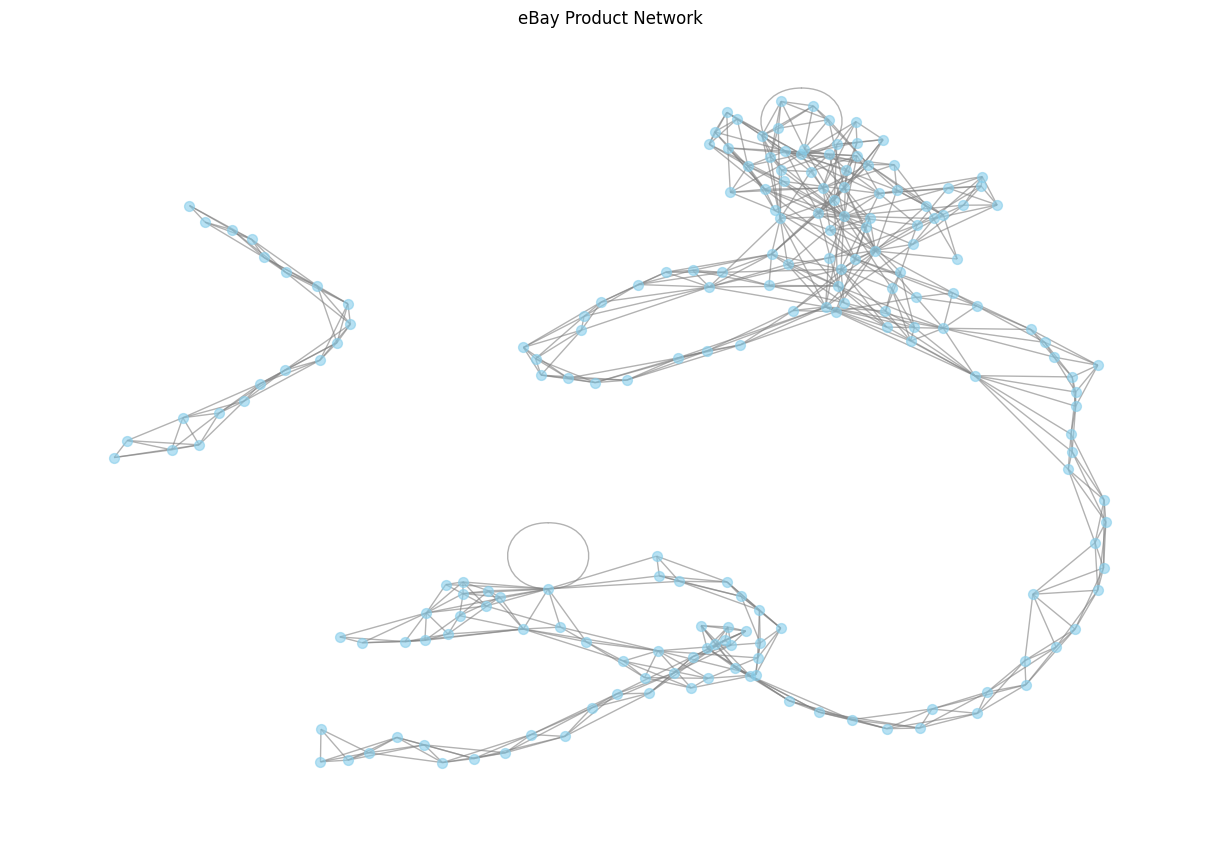

Top Key Books:
Book: The Ball Python Manual (Herpetocultural Library) -... | Centrality: 0.2418
Book: Automate the Boring Stuff with Python... | Centrality: 0.1839
Book: Python in Easy Steps by McGrath, MikeOpens in a ne... | Centrality: 0.1711
Book: Python Cookbook: Mastering Python 3... | Centrality: 0.1551
Book: Effective Python: 90 Specific Ways... | Centrality: 0.1326


In [13]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# 1. تحميل البيانات
df = pd.read_csv("DSAI_103_FINAL_SUBMISSION.csv") # تأكد إن ده اسم الملف اللي فيه الـ 230 كتاب
# دالة لتصنيف الكتب عشان نوصل الكتب اللي شبه بعض بس
def get_category(name):
    name = str(name).lower()
    if 'data' in name or 'science' in name: return 'Data'
    if 'beginner' in name or 'kids' in name: return 'Beginner'
    return 'General'

df['Category'] = df['Name'].apply(get_category) #  بنقسم الكتب لمجموعات

G = nx.Graph()
products = df['Name'].tolist()
for cat in df['Category'].unique():
    group_indices = df[df['Category'] == cat].index.tolist()

    #دي بتوصل كل كتاب بـ 3 كتب فقط من نفس فئته ده بيخلي الرسمة منظمة
    for i in range(len(group_indices)):
        for j in range(i + 1, min(i + 4, len(group_indices))):
            G.add_edge(products[group_indices[i]], products[group_indices[j]])
betweenness = nx.betweenness_centrality(G, normalized=True)
# الرسم تعديل الـ Layout عشان الرسمة متطلعش سودة
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=0.15) # الـ k بتبعد النودز عن بعض
nx.draw(
    G,
    pos,
    with_labels=False,
    node_size=50,
    node_color='skyblue',
    edge_color='gray',
    alpha=0.6
)

plt.title("eBay Product Network")
plt.show()
# نطبع أهم الكتب
print("Top Key Books:")
top_nodes = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:5]
for node, val in top_nodes:
    print(f"Book: {node[:50]}... | Centrality: {val:.4f}")

In [14]:
degree_dict = dict(G.degree())
sorted_degree = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)
print("Top 5 Most Connected Products:")
for product, degree in sorted_degree[:5]:
    print(f"{product} → Connections: {degree}")

Top 5 Most Connected Products:
Python: - The Bible- 3 Manuscripts in 1 book: -Python Programming For Beginn...Opens in a new window or tab → Connections: 23
Python in Easy Steps by McGrath, MikeOpens in a new window or tab → Connections: 18
Learning Python: Powerful Object-Oriented Programming by Lutz, MarkOpens in a new window or tab → Connections: 16
Python Programming for the Absolute Beginner, Third Edition by Dawson, MichaelOpens in a new window or tab → Connections: 15
The Quick Python BookOpens in a new window or tab → Connections: 15


In [15]:
for node in G.nodes():
    community = [node] + list(G.neighbors(node))
    print(f"Community {node}:")
    print(community[:5])

Community Python Programming for the Absolute Beginner, Third Edition by Dawson, MichaelOpens in a new window or tab:
['Python Programming for the Absolute Beginner, Third Edition by Dawson, MichaelOpens in a new window or tab', 'Python for Kids: A Playful Introduction to Programming - Paperback - GOODOpens in a new window or tab', 'New ListingCoding for Beginners Using PythonOpens in a new window or tab', "Python: 4 Books in 1: Beginner's Guide + Tips and Tricks + Best Practices + AdvOpens in a new window or tab", 'Python Programming for Beginners: An Introduction to the Python Computer...Opens in a new window or tab']
Community Python for Kids: A Playful Introduction to Programming - Paperback - GOODOpens in a new window or tab:
['Python for Kids: A Playful Introduction to Programming - Paperback - GOODOpens in a new window or tab', 'Python Programming for the Absolute Beginner, Third Edition by Dawson, MichaelOpens in a new window or tab', 'New ListingCoding for Beginners Using Pyth

In [16]:
for node in G.nodes:
    d = G.degree[node]
    print('Node:', node, '>>> Degree:', d)

Node: Python Programming for the Absolute Beginner, Third Edition by Dawson, MichaelOpens in a new window or tab >>> Degree: 15
Node: Python for Kids: A Playful Introduction to Programming - Paperback - GOODOpens in a new window or tab >>> Degree: 4
Node: New ListingCoding for Beginners Using PythonOpens in a new window or tab >>> Degree: 5
Node: Python: 4 Books in 1: Beginner's Guide + Tips and Tricks + Best Practices + AdvOpens in a new window or tab >>> Degree: 6
Node: Python: 4 Books in 1: Beginner's Gu- Charlie Masterson, 9781544877013, paperbackOpens in a new window or tab >>> Degree: 6
Node: Coding Projects in Python (DK Help Your Kids) - paperback DKOpens in a new window or tab >>> Degree: 6
Node: Coding Projects in Python (DK Help Your Kids)Opens in a new window or tab >>> Degree: 6
Node: Python QuickStart Guide: Beginner Python Programming (Spiral-Bound)Opens in a new window or tab >>> Degree: 6
Node: Python Programming for Beginners: An Introduction to the Pytho...Opens in a

In [17]:
betweenness = nx.betweenness_centrality(G, normalized=False)
for node, value in betweenness.items():
    print('Node:', node, '>>> Betweenness:', value)

Node: Python Programming for the Absolute Beginner, Third Edition by Dawson, MichaelOpens in a new window or tab >>> Betweenness: 151.64432234432235
Node: Python for Kids: A Playful Introduction to Programming - Paperback - GOODOpens in a new window or tab >>> Betweenness: 7.229700854700857
Node: New ListingCoding for Beginners Using PythonOpens in a new window or tab >>> Betweenness: 17.409462759462766
Node: Python: 4 Books in 1: Beginner's Guide + Tips and Tricks + Best Practices + AdvOpens in a new window or tab >>> Betweenness: 35.22989926739926
Node: Python: 4 Books in 1: Beginner's Gu- Charlie Masterson, 9781544877013, paperbackOpens in a new window or tab >>> Betweenness: 10.876190476190475
Node: Coding Projects in Python (DK Help Your Kids) - paperback DKOpens in a new window or tab >>> Betweenness: 10.598748473748476
Node: Coding Projects in Python (DK Help Your Kids)Opens in a new window or tab >>> Betweenness: 11.238705738705736
Node: Python QuickStart Guide: Beginner Python

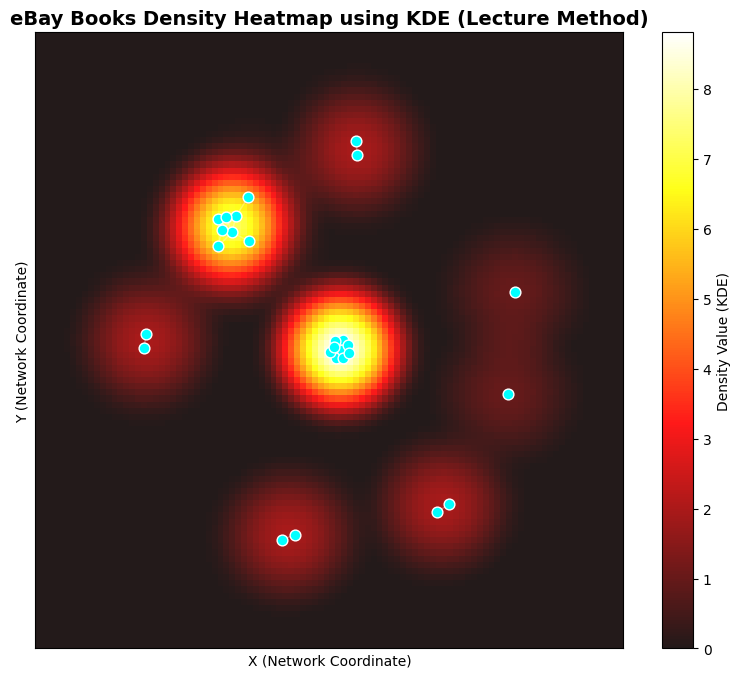

In [18]:
#Heatmaps

# بنحمل المكتبات
import pandas as pd
import networkx as nx
import numpy as np
import math
import matplotlib.pyplot as plt

df = pd.read_csv('DSAI_103_FINAL_SUBMISSION.csv')

subset = df.head(40).reset_index(drop=True) # بياخد أول 40 صف بس

G = nx.Graph()
for index, row in subset.iterrows():
    G.add_node(str(row['Name'])[:15]) # بياخد اسم الكتاب يحوله ل سترينج و يقصه ل 15 حرف و يحطه كنود في الجراف

nodes = list(G.nodes())
for i in range(len(nodes)):
    for j in range(i + 1, len(nodes)):
        w1 = set(str(nodes[i]).lower().split())
        w2 = set(str(nodes[j]).lower().split())
        if len(w1.intersection(w2)) >= 1: # لو في كلمة مشتركة بين اسمين نعمل ايدج بينهم
            G.add_edge(nodes[i], nodes[j])

pos = nx.spring_layout(G, seed=42) # بيحدد مكان كل نود باستخدام اسبرنج علشان الشكل يطلع ثابت كل مرة
X = [pos[n][0] for n in G.nodes()]
Y = [pos[n][1] for n in G.nodes()]

def kde_distance_based(d, R): # دي دالة بتحسب تأثير كل نقطة على الكثافة
    if d <= R:
        return (1 - (d/R)**2)**2
    return 0

R = 0.4

x_grid = np.linspace(min(X) - 0.5, max(X) + 0.5, 100) # بيعمل شبكة نقط من اقل لاكبر قيمة في x , y
y_grid = np.linspace(min(Y) - 0.5, max(Y) + 0.5, 100)
heatmap_data = np.zeros((len(y_grid), len(x_grid)))

for i in range(len(y_grid)):
    for j in range(len(x_grid)):
        point_y = y_grid[i]
        point_x = x_grid[j] # بيحدد مكان النقطة الحالية
        total_density = 0

        for k in range(len(X)): # يمر على كل node

            d = math.sqrt((point_x - X[k])**2 + (point_y - Y[k])**2) # يحسب المسافة بين النقطة والـ node
            total_density += kde_distance_based(d, R)

        heatmap_data[i, j] = total_density

plt.figure(figsize=(10, 8))

plt.imshow(heatmap_data, extent=(x_grid.min(), x_grid.max(), y_grid.min(), y_grid.max()),
           origin='lower', cmap='hot', alpha=0.9)
plt.colorbar(label='Density Value (KDE)')

nx.draw_networkx_nodes(G, pos, node_color='cyan', node_size=60, edgecolors='white')
nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color='white')

plt.title('eBay Books Density Heatmap using KDE (Lecture Method)', fontsize=14, fontweight='bold')
plt.xlabel('X (Network Coordinate)')
plt.ylabel('Y (Network Coordinate)')
plt.show()

In [19]:
#3D
import pandas as pd
import networkx as nx
import plotly.graph_objects as go

In [20]:

df = pd.read_csv("DSAI_103_FINAL_SUBMISSION.csv")
print(f"Total books loaded: {len(df)}")
display(df.head())

Total books loaded: 230


,Page,Name,Price,Image,Link,Method
0,1.0,"Python Programming for the Absolute Beginner, ...",$6.13,https://i.ebayimg.com/images/g/ivwAAOSwSlBYv1f...,https://www.ebay.com/itm/196893208474?_skw=pyt...,NaN
1,1.0,Introduction to Computation and Programming Us...,$39.99,https://i.ebayimg.com/images/g/8SsAAeSwpMhpaVF...,https://www.ebay.com/itm/177781117708?_skw=pyt...,NaN
2,1.0,Learning Python: Powerful Object-Oriented Prog...,$11.55,https://i.ebayimg.com/images/g/s0EAAOxyHntSX3H...,https://www.ebay.com/itm/147192308767?_skw=pyt...,NaN
3,1.0,Python Machine Learning - Paperback By Raschka...,$5.98,https://i.ebayimg.com/images/g/4jUAAOSwgLthhWu...,https://www.ebay.com/itm/275014558032?_skw=pyt...,NaN
4,1.0,A student's Guide to Python for Physical Model...,$5.00,https://i.ebayimg.com/images/g/KakAAeSwhgxpqyA...,https://www.ebay.com/itm/306807168264?_skw=pyt...,NaN


In [21]:
G = nx.Graph()
#كل كتاب =نقطه في  الشبكه و price
for index, row in df.iterrows():
    G.add_node(row['Name'], price=row['Price'])

nodes = list(G.nodes())
for i in range(len(nodes)):
    for j in range(i + 1, len(nodes)):
        w1 = set(str(nodes[i]).lower().split())
        w2 = set(str(nodes[j]).lower().split())
        if len(w1.intersection(w2)) >= 2:
            G.add_edge(nodes[i], nodes[j])

print(f"Network created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

Network created with 197 nodes and 12269 edges.


In [22]:
pos_3d = nx.spring_layout(G, dim=3, seed=42)
x_nodes = [pos_3d[n][0] for n in G.nodes()]
y_nodes = [pos_3d[n][1] for n in G.nodes()]
z_nodes = [pos_3d[n][2] for n in G.nodes()]

In [39]:
colors = []
sizes = []
symbols = []

for node in G.nodes():
    if "Python Crash" in node:
        colors.append("red")
        sizes.append(10)
        symbols.append("diamond")

    else:
        colors.append("skyblue")
        sizes.append(5)
        symbols.append("circle")

trace_nodes = go.Scatter3d(
    x=x_nodes,
    y=y_nodes,
    z=z_nodes,
    mode='markers',
    text=list(G.nodes()),
    hoverinfo='text',

    marker=dict(
        size=sizes,
        color=colors,
        symbol=symbols,
        opacity=0.8
    )
)


x_edges, y_edges, z_edges = [], [], []
for edge in G.edges():
    x_edges += [pos_3d[edge[0]][0], pos_3d[edge[1]][0], None]
    y_edges += [pos_3d[edge[0]][1], pos_3d[edge[1]][1], None]
    z_edges += [pos_3d[edge[0]][2], pos_3d[edge[1]][2], None]

centroid_x = sum(x_nodes) / len(x_nodes)
centroid_y = sum(y_nodes) / len(y_nodes)
centroid_z = sum(z_nodes) / len(z_nodes)

trace_edges = go.Scatter3d(
    x=x_edges, y=y_edges, z=z_edges,
    mode='lines',
    line=dict(color='gray', width=1),
    hoverinfo='none'
)
trace_centroid = go.Scatter3d(
    x=[centroid_x],
    y=[centroid_y],
    z=[centroid_z],

    mode='markers+text',

    marker=dict(
        size=10,
        color='gold',
        symbol='diamond'
    ),

    text=['Centroid'],
    textposition='top center',
    name='Cluster Centroid'
)



fig = go.Figure(data=[trace_edges, trace_nodes, trace_centroid])
fig.update_layout(
    title="Phase 2: 3D Point Cloud - Books Relationship Network",
    scene=dict(
        xaxis=dict(showbackground=True),
        yaxis=dict(showbackground=True),
        zaxis=dict(showbackground=True)
    )
)
fig.show()

In [24]:
#GUI
%%writefile app.py
import streamlit as st
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import os

st.set_page_config(page_title="eBay Python Books Dashboard", layout="wide")

st.title("Python Books Market Analysis Dashboard")
st.markdown("---")

@st.cache_data
def load_data():
    file_path = "DSAI_103_FINAL_SUBMISSION.csv"
    if os.path.exists(file_path):
        return pd.read_csv(file_path)
    else:
        return None

df = load_data()

if df is not None:
    st.sidebar.header("Filter & Search")
    search_query = st.sidebar.text_input("Search book title:")

    filtered_df = df.copy()
    if search_query:
        filtered_df = df[df['Name'].str.contains(search_query, case=False, na=False)]

    col_stat1, col_stat2, col_stat3 = st.columns(3)
    col_stat1.metric("Total Books", len(df))
    col_stat2.metric("Filtered Results", len(filtered_df))
    col_stat3.metric("Source", "eBay Scraper")

    st.subheader("Collected Data Explorer")
    st.dataframe(filtered_df, use_container_width=True)

    st.markdown("---")
    col1, col2 = st.columns([2, 1])

    with col1:
        st.subheader("Network Analysis (2D View)")

        G = nx.Graph()

        subset = filtered_df.head(50)
        for name in subset['Name']:
            G.add_node(name[:30] + "...")

        fig, ax = plt.subplots(figsize=(10, 6))
        pos = nx.spring_layout(G, k=0.5)
        nx.draw(G, pos, ax=ax, with_labels=True, node_size=30, node_color='skyblue', font_size=7)
        st.pyplot(fig)

    with col2:
        st.subheader("Insights & Centrality")
        st.info("Top 5 Influential Books based on Betweenness Centrality:")


        top_books = [
            "Python Crash Course",
            "Learning Python",
            "Automate the Boring Stuff",
            "Fluent Python",
            "Effective Python"
        ]
        for i, book in enumerate(top_books, 1):
            st.write(f"**{i}.** {book}")


    st.sidebar.markdown("---")
    csv = df.to_csv(index=False).encode('utf-8-sig')
    st.sidebar.download_button(
        label="Download Final Dataset (CSV)",
        data=csv,
        file_name='final_books_data.csv',
        mime='text/csv',
    )

else:
    st.error("Error: 'DSAI_103_FINAL_SUBMISSION.csv' not found. Please run the scraper first.")


st.markdown("---")
-st.markdown(
    """
    <div style="text-align: center; font-size: 35px; color: white;">
        Developed by <b>Abdelrahman Usama</b> & <b>Mariam Mohamed</b> - DSAI 103 Project
    </div>
    """,
    unsafe_allow_html=True
)

Writing app.py


In [ ]:
#"C:\Users\hp\AppData\Local\Programs\Python\Python313\Scripts\streamlit.exe" run app.py